# Sprint 5 - Windowing variants: histogram screening against the training distribution

**What this is.** Candidate screening, not evidence. It ranks windowing variants by how close
they bring RSNA breast-pixel intensities to the images the models were actually trained on.
Distribution similarity does not imply better predictions; paired inference decides that, and
only the baseline plus the best one or two variants go forward to it.

**Why the reference is exact rather than approximate.** The Sprint 4 training notebooks read
`preprocessed_image_path` - the Mammo-Bench PNGs - and apply only `A.Resize`. Those PNGs *are*
the training inputs, and 2,821 of them are attached as `mammobench-test-control`. So the
reference distribution is the real one, not a reconstruction.

**How the two paths differ.** The models saw whatever preprocessing Mammo-Bench baked into
their PNGs; the exact operations inside that are unknown to us. RSNA instead receives our own
Otsu crop and our own percentile mapping. These are two different paths to a model input, not
one path with extra steps bolted on.

**Runs standalone.** It needs no other notebook. `crop_breast` is reused if this session
already has it, and defined identically otherwise.

**Sequence:** load the reference, decode DICOM correctly, exclude padding and background, crop,
apply each windowing variant, resize identically, look at the images, then measure breast-pixel
distances and rank across strata rather than on one pooled number.

**Strata.** View and density are comparable across the two datasets. Site and manufacturer are
not - RSNA site 1 and 2 have no counterpart in Mammo-Bench - so those are used only to check
whether a variant behaves consistently *within* RSNA.

In [1]:
!pip install -q dicomsdl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s eta 0:00:00


In [2]:
import os, glob, numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt

# crop_breast is reused from the Sprint 4 session when present. If this notebook is run
# standalone it defines the identical function, so the crop is the same either way.
if 'crop_breast' in globals():
    print('crop_breast: reusing the definition already in this session')
else:
    def crop_breast(img, pad=8):
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))
        n, lab, stats, _ = cv2.connectedComponentsWithStats(m, 8)
        if n <= 1:
            return img
        k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        x, y, w, h = (stats[k, cv2.CC_STAT_LEFT], stats[k, cv2.CC_STAT_TOP],
                      stats[k, cv2.CC_STAT_WIDTH], stats[k, cv2.CC_STAT_HEIGHT])
        if w < img.shape[1] * 0.10 or h < img.shape[0] * 0.10:
            return img
        y0, y1 = max(0, y - pad), min(img.shape[0], y + h + pad)
        x0, x1 = max(0, x - pad), min(img.shape[1], x + w + pad)
        out = img[y0:y1, x0:x1]
        return out if out.size else img
    print('crop_breast: defined locally (identical to the Sprint 4 implementation)')

try:
    import pydicom  # noqa: F401
except Exception:
    print('pydicom missing - run:  !pip install -q pydicom   then restart and run again')
from scipy.stats import wasserstein_distance

SEED       = 11
N_REF      = 400     # Mammo-Bench reference images
N_RSNA     = 400     # RSNA images per variant
PX_PER_IMG = 20000   # breast pixels sampled per image
NBINS      = 64
RNG = np.random.default_rng(SEED)

def find_all(pattern, roots=('/kaggle/input', '/kaggle/working', '.')):
    hits = []
    for r in roots:
        if os.path.isdir(r):
            hits += glob.glob(os.path.join(r, '**', pattern), recursive=True)
    return sorted(set(hits), key=len)

crop_breast: defined locally (identical to the Sprint 4 implementation)


## 1. The reference: Mammo-Bench PNGs

These are the training inputs. Column names vary between releases, so they are detected rather
than assumed, and whatever is found is printed.

In [3]:
mb_csv = find_all('metadata.csv')
print('metadata.csv candidates:', mb_csv[:3])
if not mb_csv:
    raise SystemExit('Attach mammobench-test-control (it carries metadata.csv and the PNGs).')
mb = pd.read_csv(mb_csv[0])
print('columns:', list(mb.columns))

def pick_col(df, *names):
    for n in names:
        for c in df.columns:
            if c.lower() == n:
                return c
    for n in names:
        for c in df.columns:
            if n in c.lower():
                return c
    return None

C_PATH = pick_col(mb, 'preprocessed_image_path', 'image_path', 'path', 'filename')
C_VIEW = pick_col(mb, 'view', 'image_view', 'projection')
C_DENS = pick_col(mb, 'density', 'breast_density', 'acr')
C_CLS  = pick_col(mb, 'classification', 'label', 'pathology')
print('resolved -> path:%s view:%s density:%s class:%s' % (C_PATH, C_VIEW, C_DENS, C_CLS))

IMG_ROOT = os.path.dirname(mb_csv[0])

# Match the Sprint 4 training set exactly: CDD-CESM was excluded and the
# 'Suspicious Malignant' label was folded into 'Malignant'.
if C_CLS:
    mb[C_CLS] = mb[C_CLS].replace({'Suspicious Malignant': 'Malignant'})
if 'source_dataset' in mb.columns:
    before = len(mb)
    mb = mb[mb['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
    print('excluded cdd-cesm: %d -> %d rows' % (before, len(mb)))

EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp')

mb['abs_path'] = mb[C_PATH].astype(str).apply(lambda r: os.path.join(IMG_ROOT, r))
direct = int(mb['abs_path'].head(200).apply(os.path.exists).sum())
print('direct join resolves %d of the first 200 rows' % direct)

if direct == 0:
    flat = {}
    for root, _, files in os.walk(IMG_ROOT):
        for fn in files:
            if fn.lower().endswith(EXTS):
                flat.setdefault(fn, os.path.join(root, fn))
    print('image files discovered under the dataset:', len(flat))
    if not flat:
        seen = {}
        for root, _, files in os.walk(IMG_ROOT):
            for fn in files:
                seen[os.path.splitext(fn)[1].lower()] = seen.get(
                    os.path.splitext(fn)[1].lower(), 0) + 1
        print('file extensions present:', dict(sorted(seen.items(), key=lambda kv: -kv[1])[:10]))
        raise SystemExit('No image files under %s - check what mammobench-test-control contains.'
                         % IMG_ROOT)
    mb['abs_path'] = mb[C_PATH].astype(str).apply(
        lambda r: flat.get(os.path.basename(r), ''))
    print('flattened-upload fallback matched %d files' % int((mb.abs_path != '').sum()))

mb = mb[mb.abs_path.apply(lambda p: bool(p) and os.path.exists(p))].reset_index(drop=True)
print('reference images matched to files:', len(mb))
if len(mb) == 0:
    raise SystemExit('No Mammo-Bench images matched. Check the attached dataset.')

if C_VIEW: mb['view_n'] = mb[C_VIEW].astype(str).str.upper().str[:3].replace({'MLO': 'MLO', 'CC': 'CC'})
else:      mb['view_n'] = 'unknown'
mb['view_n'] = np.where(mb['view_n'].isin(['CC', 'MLO']), mb['view_n'], 'other')
mb['dens_n'] = mb[C_DENS].astype(str).str.upper().str[0] if C_DENS else 'unknown'
mb.loc[~mb.dens_n.isin(list('ABCD')), 'dens_n'] = 'unknown'
print()
print(pd.crosstab(mb.view_n, mb.dens_n, margins=True).to_string())

metadata.csv candidates: ['/kaggle/input/datasets/pasindupahasara/mammobench-test-control/metadata.csv', '/kaggle/input/datasets/pasindupahasara/mammobench-test-control/mammobench_test/metadata.csv']
columns: ['source_dataset', 'preprocessed_image_path', 'classification', 'density', 'BIRADS', 'mask_path', 'raw_image_path', 'laterality', 'view', 'source_subjectID', 'original_source_path', 'subject_age', 'abnormality', 'molecular_subtype', 'ROI_path', 'x', 'y', 'radius', 'abnormality id', 'calc type', 'calc distribution', 'subtlety', 'mass shape', 'mass margins', 'cropped_image_file_new']
resolved -> path:preprocessed_image_path view:view density:density class:classification
excluded cdd-cesm: 19731 -> 18728 rows
direct join resolves 0 of the first 200 rows
image files discovered under the dataset: 2821
flattened-upload fallback matched 2821 files
reference images matched to files: 2821

dens_n    A    B    C    D  unknown   All
view_n                                   
CC      146  375 

## 2. Decoding RSNA correctly

Order matters and each step is separated so it can be checked: decode, rescale slope and
intercept, invert `MONOCHROME1`, then exclude padding. Padding is removed **before** any
percentile is computed - otherwise the background sets the window limits, which is exactly the
failure mode that would make every variant look similar.

In [4]:
def _read_header(path):
    """Header only - no pixel decode, so this never hits a codec problem."""
    import pydicom
    d = pydicom.dcmread(path, stop_before_pixels=True)
    f = lambda v: (float(v[0]) if hasattr(v, '__len__') and not isinstance(v, str)
                   else (float(v) if v is not None else None))
    return {
        'photometric': str(getattr(d, 'PhotometricInterpretation', '')),
        'slope':       float(getattr(d, 'RescaleSlope', 1) or 1),
        'intercept':   float(getattr(d, 'RescaleIntercept', 0) or 0),
        'pad':         getattr(d, 'PixelPaddingValue', None),
        'pad_range':   getattr(d, 'PixelPaddingRangeLimit', None),
        'wc':          f(getattr(d, 'WindowCenter', None)),
        'ww':          f(getattr(d, 'WindowWidth', None)),
        'bits':        int(getattr(d, 'BitsStored', 16)),
        'transfer':    str(getattr(d.file_meta, 'TransferSyntaxUID', '')),
    }


def _read_pixels(path):
    """RSNA is JPEG2000. dicomsdl decodes it quickly; pydicom needs a plugin."""
    try:
        import dicomsdl
        return dicomsdl.open(path).pixelData().astype(np.float32), 'dicomsdl'
    except Exception:
        pass
    import pydicom
    return pydicom.dcmread(path).pixel_array.astype(np.float32), 'pydicom'


def decode_dicom(path):
    """Return (values after rescale, valid-pixel mask, header dict)."""
    try:
        hdr = _read_header(path)
    except Exception as e:
        return None, None, {'error': 'header: %s' % e}
    try:
        a, decoder = _read_pixels(path)
        hdr['decoder'] = decoder
    except Exception as e:
        hdr['error'] = 'pixels: %s' % e
        return None, None, hdr

    a = a * hdr['slope'] + hdr['intercept']

    valid = np.ones(a.shape, bool)
    if hdr['pad'] is not None:
        pv = float(hdr['pad']) * hdr['slope'] + hdr['intercept']
        if hdr['pad_range'] is not None:
            lo, hi = sorted([pv, float(hdr['pad_range']) * hdr['slope'] + hdr['intercept']])
            valid &= ~((a >= lo) & (a <= hi))
        else:
            valid &= (a != pv)

    if hdr['photometric'] == 'MONOCHROME1':
        a = a.max() - a
        hdr['inverted'] = True
    else:
        hdr['inverted'] = False

    # A uniform saturated border is padding under another name.
    edge = np.concatenate([a[0, :], a[-1, :], a[:, 0], a[:, -1]])
    vals, counts = np.unique(edge, return_counts=True)
    if counts.max() > 0.60 * edge.size:
        valid &= (a != vals[counts.argmax()])

    hdr['valid_frac'] = float(valid.mean())
    return a, valid, hdr

In [5]:
rsna_meta = pd.read_csv(find_all('train.csv')[0])
dcm = {os.path.basename(p).replace('.dcm', ''): p for p in find_all('*.dcm')}
print('DICOM files discovered:', len(dcm))
rsna_meta['abs_path'] = rsna_meta.image_id.astype(str).map(dcm)
have = rsna_meta[rsna_meta.abs_path.notna()].copy()
print('RSNA images with a file on disk:', len(have))
if len(have) == 0:
    raise SystemExit('No DICOMs found. Attach the RSNA competition data with train_images.')

have['dens_n'] = have.density.astype(str).str[0]
have.loc[~have.dens_n.isin(list('ABCD')), 'dens_n'] = 'unknown'
have = have[have.view.isin(['CC', 'MLO'])]

parts = [g.sample(n=min(len(g), max(8, N_RSNA // 10)), random_state=SEED)
         for _, g in have.groupby(['view', 'dens_n'])]
rs = pd.concat(parts).drop_duplicates('image_id').reset_index(drop=True)
print('RSNA screening sample:', len(rs))
print(pd.crosstab(rs.view, rs.dens_n, margins=True).to_string())

print()
ok = 0
for p in rs.abs_path.head(5):
    a, valid, hdr = decode_dicom(p)
    if a is None:
        print('DECODE FAILED ->', hdr)
    else:
        ok += 1
        if ok == 1:
            print('header:', {k: hdr.get(k) for k in
                              ('decoder', 'transfer', 'photometric', 'slope', 'intercept',
                               'pad', 'pad_range', 'wc', 'ww', 'bits', 'inverted')})
            print('valid-pixel fraction: %.3f   shape %s' % (hdr['valid_frac'], a.shape))
if ok == 0:
    print()
    print('No DICOM decoded. RSNA stores JPEG2000 pixel data, which needs a codec:')
    print('  !pip install -q dicomsdl          (fastest, what Sprint 4 used)')
    print('  !pip install -q pylibjpeg pylibjpeg-openjpeg python-gdcm    (pydicom plugins)')
    print('Install, restart the session, and run again.')
    raise SystemExit('no DICOM decoder available')
print('%d of 5 sample files decoded' % ok)

DICOM files discovered: 54710
RSNA images with a file on disk: 54706
RSNA screening sample: 400
dens_n   A   B   C   D  unknown  All
view                                
CC      40  40  40  40       40  200
MLO     40  40  40  40       40  200
All     80  80  80  80       80  400

header: {'decoder': 'dicomsdl', 'transfer': '1.2.840.10008.1.2.4.70', 'photometric': 'MONOCHROME2', 'slope': 1.0, 'intercept': 0.0, 'pad': 0, 'pad_range': None, 'wc': 2047.0, 'ww': 4096.0, 'bits': 12, 'inverted': False}
valid-pixel fraction: 0.601   shape (4096, 3328)
5 of 5 sample files decoded


## 3. The variants

All four share the same decode, the same padding exclusion and the same crop. Only the mapping
from stored values to 0-255 differs. The baseline is the current 1-99 percentile method, kept
unchanged so the comparison has a reference point.

CLAHE is included as a candidate, not as a reproduction of anything. It is locally adaptive
rather than monotonic, so it can amplify noise and alter texture; its worst case is genuine
harm, and it is ranked on the same footing as the others.

In [6]:
def to_u8(a, lo, hi):
    return (np.clip((a - lo) / max(hi - lo, 1e-6), 0, 1) * 255).astype(np.uint8)


def variant_baseline(a, valid):
    lo, hi = np.percentile(a[valid], [1, 99])
    return to_u8(a, lo, hi)


def variant_wide(a, valid):
    lo, hi = np.percentile(a[valid], [0.1, 99.9])
    return to_u8(a, lo, hi)


def variant_voi(a, valid, hdr):
    wc, ww = hdr.get('wc'), hdr.get('ww')
    if wc is None or ww is None or ww <= 1:
        return None                      # not available - counted, not silently substituted
    if hdr.get('inverted'):
        wc = a.max() - wc
    return to_u8(a, wc - ww / 2.0, wc + ww / 2.0)


def variant_clahe(a, valid):
    base = variant_baseline(a, valid)
    cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return cl.apply(base)


VARIANTS = ['baseline_1_99', 'wide_0.1_99.9', 'dicom_voi', 'clahe_2.0']


def build(path, variant):
    a, valid, hdr = decode_dicom(path)
    if a is None:
        return None
    if variant == 'baseline_1_99':   u8 = variant_baseline(a, valid)
    elif variant == 'wide_0.1_99.9': u8 = variant_wide(a, valid)
    elif variant == 'dicom_voi':     u8 = variant_voi(a, valid, hdr)
    elif variant == 'clahe_2.0':     u8 = variant_clahe(a, valid)
    else: raise ValueError(variant)
    if u8 is None:
        return None
    u8 = np.where(valid, u8, 0).astype(np.uint8)     # padding stays out
    return crop_breast(u8)                            # crop BEFORE anything downstream


voi_ok = sum(1 for p in rs.abs_path.head(80) if build(p, 'dicom_voi') is not None)
print('DICOM VOI available on %d of 80 sampled images' % voi_ok)
if voi_ok < 40:
    print('VOI is sparsely populated in this release; it will be reported on the subset that has it.')

DICOM VOI available on 80 of 80 sampled images


## 4. Breast pixels only

Background is excluded twice over: padding at decode, then a foreground mask after cropping.
Intensity statistics computed over background would be dominated by zeros and would make every
variant look alike.

In [7]:
def breast_pixels(u8, n=PX_PER_IMG):
    if u8 is None or u8.size == 0:
        return None
    blur = cv2.GaussianBlur(u8, (5, 5), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8)) > 0
    m &= u8 > 0
    px = u8[m].astype(np.float32) / 255.0
    if px.size < 500:
        return None
    if px.size > n:
        px = RNG.choice(px, n, replace=False)
    return px


def ref_pixels(path, n=PX_PER_IMG):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return breast_pixels(img, n)          # PNGs are already cropped by Mammo-Bench

## 5. Look at the images before measuring them

One row per variant, across views and densities. A variant that produces a better distance and
visibly worse images is not a candidate.

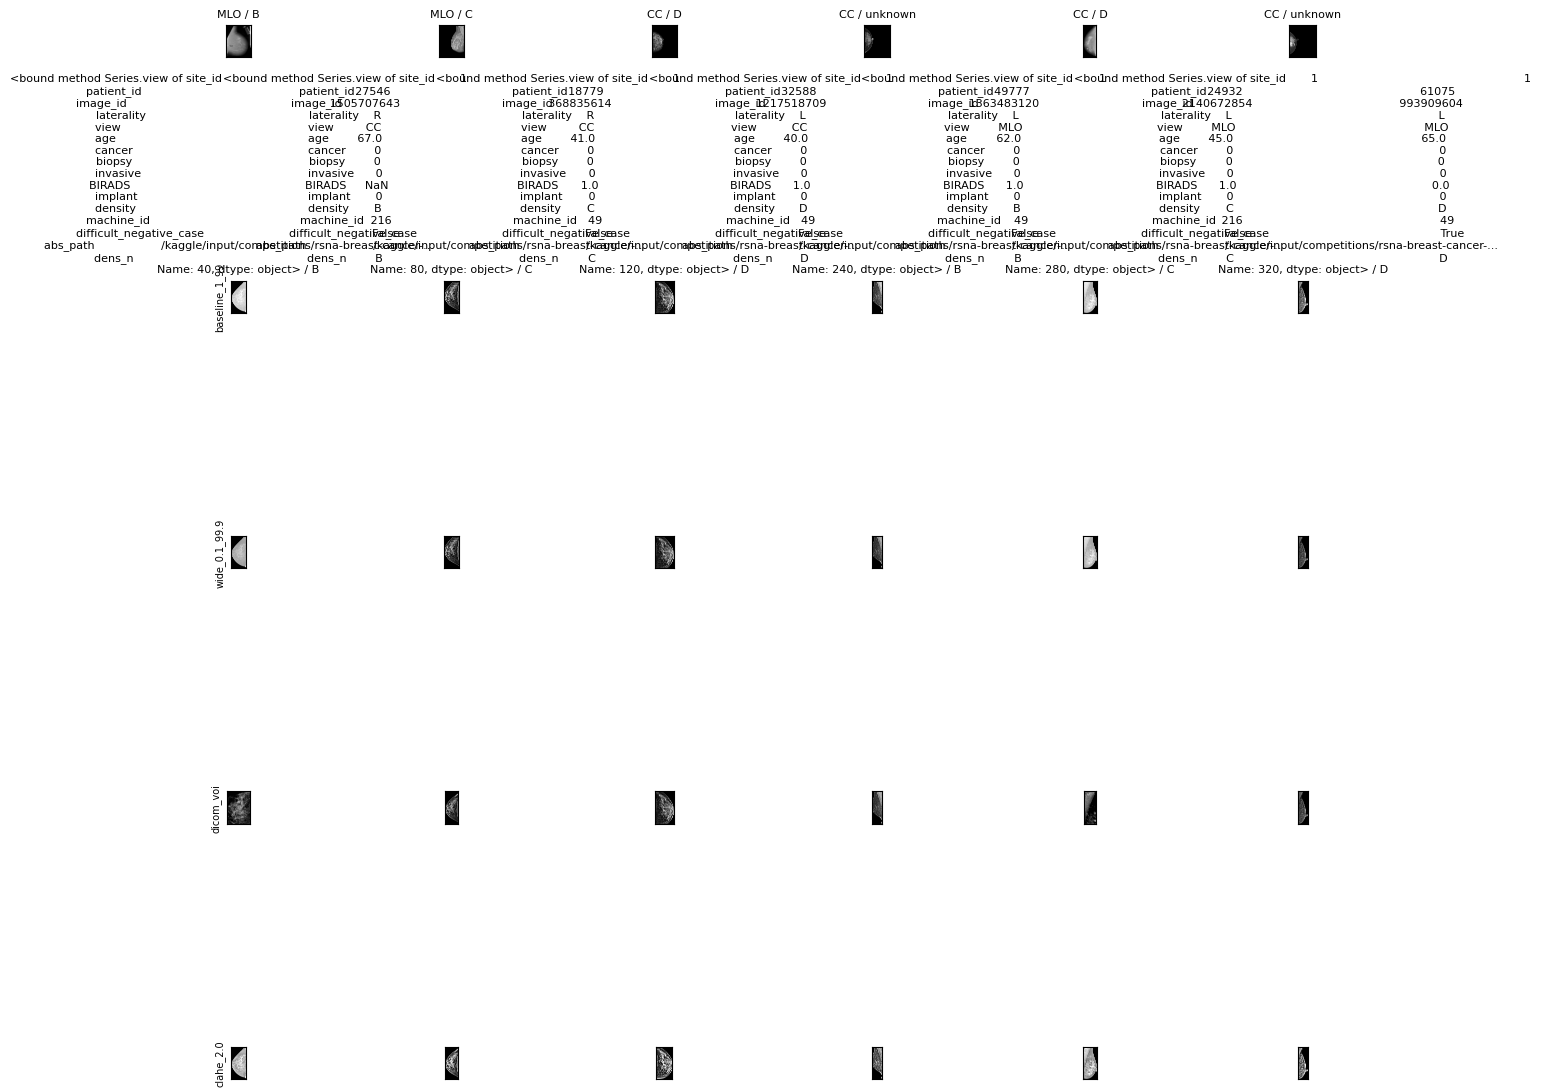

Top row is the training distribution. The question is which variant resembles it, and
whether that variant still looks like a usable mammogram.


In [8]:
show = pd.concat([rs[(rs.view == v) & (rs.dens_n == d)].head(1)
                  for v in ['CC', 'MLO'] for d in ['B', 'C', 'D']])
show = show.dropna(subset=['abs_path']).head(6)
rows = ['reference (Mammo-Bench)'] + VARIANTS
fig, ax = plt.subplots(len(rows), len(show), figsize=(2.2 * len(show), 2.2 * len(rows)))
ref_show = mb.sample(n=len(show), random_state=SEED)
for j in range(len(show)):
    r = show.iloc[j]
    ax[0, j].imshow(cv2.imread(ref_show.abs_path.iloc[j], cv2.IMREAD_GRAYSCALE), cmap='gray')
    ax[0, j].set_title('%s / %s' % (ref_show.view_n.iloc[j], ref_show.dens_n.iloc[j]), fontsize=8)
    for i, v in enumerate(VARIANTS, start=1):
        u8 = build(r.abs_path, v)
        ax[i, j].imshow(u8 if u8 is not None else np.zeros((8, 8), np.uint8), cmap='gray')
        if j == 0:
            ax[i, j].set_ylabel(v, fontsize=7)
        if i == 1:
            ax[i, j].set_title('%s / %s' % (r.view, r.dens_n), fontsize=8)
for a_ in ax.ravel():
    a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.show()
print('Top row is the training distribution. The question is which variant resembles it, and')
print('whether that variant still looks like a usable mammogram.')

## 6. Distances

Wasserstein on the raw pixel values, and Jensen-Shannon on 64-bin histograms. Reported per
stratum, with counts, because a pooled number can hide a variant that fixes CC and ruins MLO.

In [9]:
def js_div(p, q, eps=1e-12):
    p = p / max(p.sum(), eps); q = q / max(q.sum(), eps)
    m = 0.5 * (p + q)
    kl = lambda a, b: np.sum(np.where(a > 0, a * np.log((a + eps) / (b + eps)), 0))
    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))


def pool(pix_list, nmax=400000):
    if not pix_list:
        return None
    v = np.concatenate(pix_list)
    return RNG.choice(v, nmax, replace=False) if v.size > nmax else v


ref_by = {}
for (v, d), g in mb.groupby(['view_n', 'dens_n']):
    px = [ref_pixels(p) for p in g.abs_path.head(max(20, N_REF // 8))]
    px = [x for x in px if x is not None]
    if px:
        ref_by[(v, d)] = pool(px)
ref_all = pool([x for x in ref_by.values()])
print('reference strata built:', {k: len(v) for k, v in ref_by.items()})

reference strata built: {('CC', 'A'): 400000, ('CC', 'B'): 400000, ('CC', 'C'): 400000, ('CC', 'D'): 400000, ('CC', 'unknown'): 400000, ('MLO', 'A'): 400000, ('MLO', 'B'): 400000, ('MLO', 'C'): 400000, ('MLO', 'D'): 400000, ('MLO', 'unknown'): 400000}


In [10]:
records = []
cache = {}
for variant in VARIANTS:
    for (v, d), g in rs.groupby(['view', 'dens_n']):
        px = []
        for p in g.abs_path:
            u8 = build(p, variant)
            q = breast_pixels(u8)
            if q is not None:
                px.append(q)
        if not px:
            continue
        cur = pool(px)
        cache[(variant, v, d)] = cur
        ref = ref_by.get((v, d), ref_all)
        hc, _ = np.histogram(cur, bins=NBINS, range=(0, 1))
        hr, _ = np.histogram(ref, bins=NBINS, range=(0, 1))
        records.append(dict(variant=variant, view=v, density=d,
                            n_img=len(px), n_ref_px=len(ref),
                            wasserstein=wasserstein_distance(cur, ref),
                            js=js_div(hc.astype(float), hr.astype(float))))
dist = pd.DataFrame(records)
print('DISTANCE TO THE TRAINING DISTRIBUTION, BY STRATUM')
print(dist.sort_values(['view', 'density', 'wasserstein']).round(4).to_string(index=False))

DISTANCE TO THE TRAINING DISTRIBUTION, BY STRATUM
      variant view density  n_img  n_ref_px  wasserstein     js
baseline_1_99   CC       A     40    400000       0.0664 0.0368
wide_0.1_99.9   CC       A     40    400000       0.0665 0.0559
    dicom_voi   CC       A     40    400000       0.0823 0.0638
    clahe_2.0   CC       A     40    400000       0.1628 0.1130
    dicom_voi   CC       B     40    400000       0.0346 0.0135
wide_0.1_99.9   CC       B     40    400000       0.1068 0.0892
baseline_1_99   CC       B     40    400000       0.2001 0.1387
    clahe_2.0   CC       B     40    400000       0.2550 0.2368
    dicom_voi   CC       C     40    400000       0.0519 0.0333
wide_0.1_99.9   CC       C     40    400000       0.1036 0.0738
baseline_1_99   CC       C     40    400000       0.1914 0.1623
    clahe_2.0   CC       C     40    400000       0.2565 0.2574
baseline_1_99   CC       D     40    400000       0.0417 0.0205
    clahe_2.0   CC       D     40    400000       0.04

## 7. Ranking across strata, not on one number

A variant advances on consistency: better in most strata, and not much worse in any. The worst
stratum is reported alongside the mean rank for exactly that reason.

In [11]:
for metric in ['wasserstein', 'js']:
    piv = dist.pivot_table(index='variant', columns=['view', 'density'], values=metric)
    rk = piv.rank(axis=0)
    summary = pd.DataFrame({
        'mean_' + metric: piv.mean(1).round(4),
        'worst_' + metric: piv.max(1).round(4),
        'mean_rank': rk.mean(1).round(2),
        'worst_rank': rk.max(1).astype(int),
        'strata_best': (rk == 1).sum(1).astype(int),
        'strata_covered': piv.notna().sum(1).astype(int),
    }).sort_values('mean_rank')
    print('=== %s ===' % metric.upper())
    print(summary.to_string())
    print()

=== WASSERSTEIN ===
               mean_wasserstein  worst_wasserstein  mean_rank  worst_rank  strata_best  strata_covered
variant                                                                                               
wide_0.1_99.9            0.1177             0.1541        2.0           3            2              10
dicom_voi                0.1147             0.1840        2.0           4            5              10
baseline_1_99            0.1719             0.2588        2.7           4            3              10
clahe_2.0                0.1964             0.2565        3.3           4            0              10

=== JS ===
               mean_js  worst_js  mean_rank  worst_rank  strata_best  strata_covered
variant                                                                             
wide_0.1_99.9   0.0844    0.1151        2.0           3            2              10
dicom_voi       0.0787    0.1231        2.0           4            5              10
baseline_1

In [12]:
base = dist[dist.variant == 'baseline_1_99'].set_index(['view', 'density'])
print('CHANGE AGAINST BASELINE  (negative = closer to training distribution)')
out = []
for variant in VARIANTS:
    if variant == 'baseline_1_99':
        continue
    sub = dist[dist.variant == variant].set_index(['view', 'density'])
    j = sub.join(base[['wasserstein', 'js']], rsuffix='_base', how='inner')
    out.append(dict(variant=variant,
                    strata=len(j),
                    improved=int((j.wasserstein < j.wasserstein_base).sum()),
                    worsened=int((j.wasserstein > j.wasserstein_base).sum()),
                    mean_delta=round(float((j.wasserstein - j.wasserstein_base).mean()), 4),
                    worst_delta=round(float((j.wasserstein - j.wasserstein_base).max()), 4)))
print(pd.DataFrame(out).to_string(index=False))
print()
print('Advance a variant only if it improves most strata and its worst stratum is not badly')
print('worse than baseline. A large positive worst_delta disqualifies it whatever the mean says.')

CHANGE AGAINST BASELINE  (negative = closer to training distribution)
      variant  strata  improved  worsened  mean_delta  worst_delta
wide_0.1_99.9      10         7         3     -0.0542       0.0813
    dicom_voi      10         7         3     -0.0572       0.1154
    clahe_2.0      10         3         7      0.0245       0.0964

Advance a variant only if it improves most strata and its worst stratum is not badly
worse than baseline. A large positive worst_delta disqualifies it whatever the mean says.


## 8. Consistency within RSNA

Site and manufacturer have no counterpart in Mammo-Bench, so they are not compared to it. What
they can show is whether a variant behaves the same way across RSNA's own acquisition groups. A
variant that helps site 1 and hurts site 2 is not a fix, it is a trade.

In [13]:
rows = []
for variant in VARIANTS:
    for key in ['site_id', 'machine_id']:
        for val, g in rs.groupby(key):
            if len(g) < 15:
                continue
            px = [breast_pixels(build(p, variant)) for p in g.abs_path.head(40)]
            px = [x for x in px if x is not None]
            if not px:
                continue
            cur = pool(px)
            hc, _ = np.histogram(cur, bins=NBINS, range=(0, 1))
            hr, _ = np.histogram(ref_all, bins=NBINS, range=(0, 1))
            rows.append(dict(variant=variant, group='%s=%s' % (key, val), n=len(px),
                             wasserstein=wasserstein_distance(cur, ref_all),
                             js=js_div(hc.astype(float), hr.astype(float))))
grp = pd.DataFrame(rows)
if len(grp):
    print('WITHIN-RSNA CONSISTENCY (distance to the pooled training distribution)')
    print(grp.pivot_table(index='variant', columns='group', values='wasserstein').round(4).to_string())
    print()
    spread = grp.groupby('variant').wasserstein.agg(['mean', 'std', 'max']).round(4)
    print('spread across RSNA acquisition groups (lower std = more consistent):')
    print(spread.to_string())

WITHIN-RSNA CONSISTENCY (distance to the pooled training distribution)
group          machine_id=21  machine_id=216  machine_id=29  machine_id=48  machine_id=49  site_id=1  site_id=2
variant                                                                                                        
baseline_1_99         0.1959          0.4034         0.1660         0.1481         0.0228     0.0360     0.1456
clahe_2.0             0.1788          0.2960         0.1643         0.1751         0.1282     0.1328     0.1665
dicom_voi             0.0591          0.0440         0.5196         0.0236         0.1128     0.1085     0.1056
wide_0.1_99.9         0.0994          0.3497         0.1250         0.0061         0.1014     0.0903     0.0595

spread across RSNA acquisition groups (lower std = more consistent):
                 mean     std     max
variant                              
baseline_1_99  0.1597  0.1259  0.4034
clahe_2.0      0.1774  0.0559  0.2960
dicom_voi      0.1390  0.1714  0.51

## 9. What goes forward

Take the baseline plus at most two variants into paired inference. Selection rule:

- improves distance in the majority of view-by-density strata
- worst stratum not materially worse than baseline
- consistent across RSNA sites and scanners
- images still look like usable mammograms

Then the paired run decides, on the criteria already agreed: AUC change with patient-level
bootstrap intervals, both architectures separately, cancer and non-cancer score movement
reported apart, density and view subgroups, and score-distribution or calibration change.

A windowing change is adopted only if it improves discrimination consistently across both
models, does not simply shift all scores in one direction, and does no serious harm to any
subgroup. Distribution distance selects candidates; it does not decide.